<a href="https://colab.research.google.com/github/GyanAnargya/Kumpulan-Hasil-Tugas-Besar/blob/main/TUBES_PSWD_IIR_EEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelompok 1
Anggota :
*   Revina Agnanta
*   Rizka Ayu Susanti
*   Sakti Risla Syah Putra
*   Dayangku NuruL Hafizah
*   Nadya Wulandari






Case : Menghilangkan derau Noise Pada Sinyal EEG [ ADHD ] Menggunakan Metode IIR ( Butterworth dan cybesev)

Mounted at /content/drive
Membaca file dari: /content/drive/MyDrive/Datasheet EEG.csv...
✅ Data berhasil dimuat: 49999 sampel.


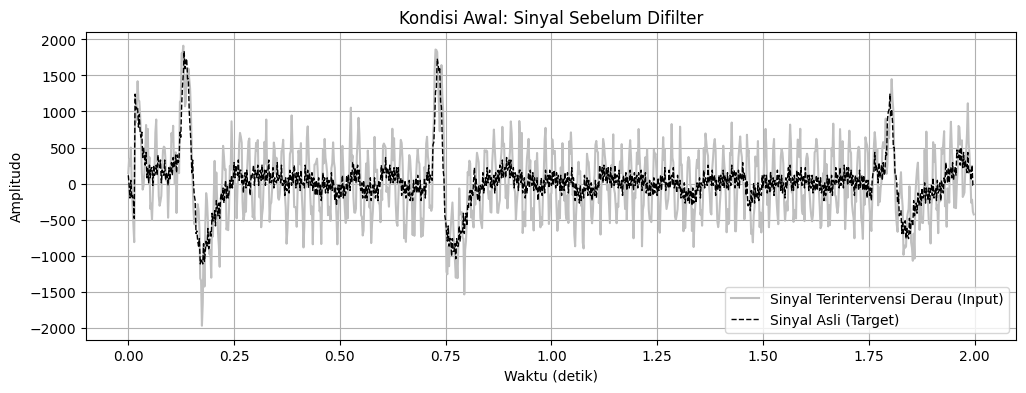

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
from google.colab import drive


drive.mount('/content/drive', force_remount=True)
path_file = '/content/drive/MyDrive/Datasheet EEG.csv'

print(f"Membaca file dari: {path_file}...")
try:

    df = pd.read_csv(path_file, nrows=50000, header=None, sep=None, engine='python')
    raw = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().values
    if len(raw) == 0: raise ValueError("Data kosong.")
    print(f"✅ Data berhasil dimuat: {len(raw)} sampel.")
except Exception as e:
    print(f"⚠️ Error baca file: {e}. Menggunakan dummy data.")
    raw = np.sin(2*np.pi*5*np.linspace(0, 10, 5000))

# 2. Konfigurasi Parameter (Sesuai Alat)
fs = 500.0         # Sampling Rate (Hz)
cutoff = 30.0      # Cutoff Frequency (Hz)
order = 4          # Orde Filter
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
n = len(raw)
t = np.linspace(0, n/fs, n, endpoint=False)


#buat 'eeg_clean' dan 'eeg_noisy'
eeg_clean = raw - np.mean(raw)

noise = np.random.normal(0, 0.5 * np.std(eeg_clean), n) + \
        (1.5 * np.std(eeg_clean) * np.sin(2 * np.pi * 50 * t))
eeg_noisy = eeg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t[:1000], eeg_noisy[:1000], 'silver', label='Sinyal Terintervensi Derau (Input)')
plt.plot(t[:1000], eeg_clean[:1000], 'k--', linewidth=1, label='Sinyal Asli (Target)')
plt.title('Kondisi Awal: Sinyal Sebelum Difilter')
plt.xlabel('Waktu (detik)'); plt.ylabel('Amplitudo')
plt.legend(); plt.grid(True); plt.show()

Selanjutnya kita analisis menggunakan metode butterworth

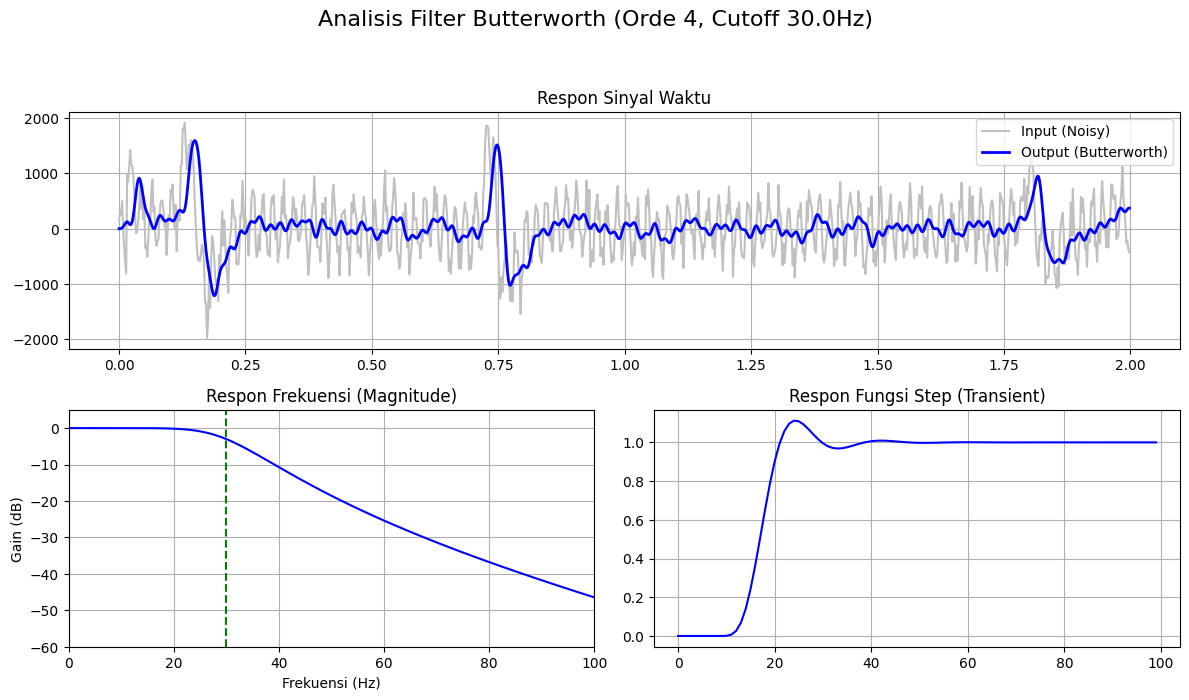

In [ ]:
b_butt, a_butt = signal.butter(order, normal_cutoff, btype='low', analog=False)
eeg_filtered_butt = signal.lfilter(b_butt, a_butt, eeg_noisy)

plt.figure(figsize=(12, 10))
plt.suptitle(f"Analisis Filter Butterworth (Orde {order}, Cutoff {cutoff}Hz)", fontsize=16)

plt.subplot(3, 1, 1)
plt.plot(t[:1000], eeg_noisy[:1000], 'silver', label='Input (Noisy)')
plt.plot(t[:1000], eeg_filtered_butt[:1000], 'b', linewidth=2, label='Output (Butterworth)')
plt.title('Respon Sinyal Waktu')
plt.legend(loc='upper right'); plt.grid(True)

w, h = signal.freqz(b_butt, a_butt)
plt.subplot(3, 2, 3)
plt.plot(w * fs / (2 * np.pi), 20 * np.log10(abs(h)), 'b')
plt.title('Respon Frekuensi (Magnitude)')
plt.ylabel('Gain (dB)'); plt.xlabel('Frekuensi (Hz)')
plt.axvline(cutoff, color='g', linestyle='--'); plt.ylim(-60, 5); plt.xlim(0, 100); plt.grid(True)

step_in = np.ones(100); step_in[0:10] = 0
step_out = signal.lfilter(b_butt, a_butt, step_in)
plt.subplot(3, 2, 4)
plt.plot(step_out, 'b')
plt.title('Respon Fungsi Step (Transient)')
plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Analisis Singkat: Grafik ini menunjukkan karakteristik Butterworth yang "mulus". Perhatikan passband (0-30Hz) di grafik frekuensi yang datar tanpa gelombang.

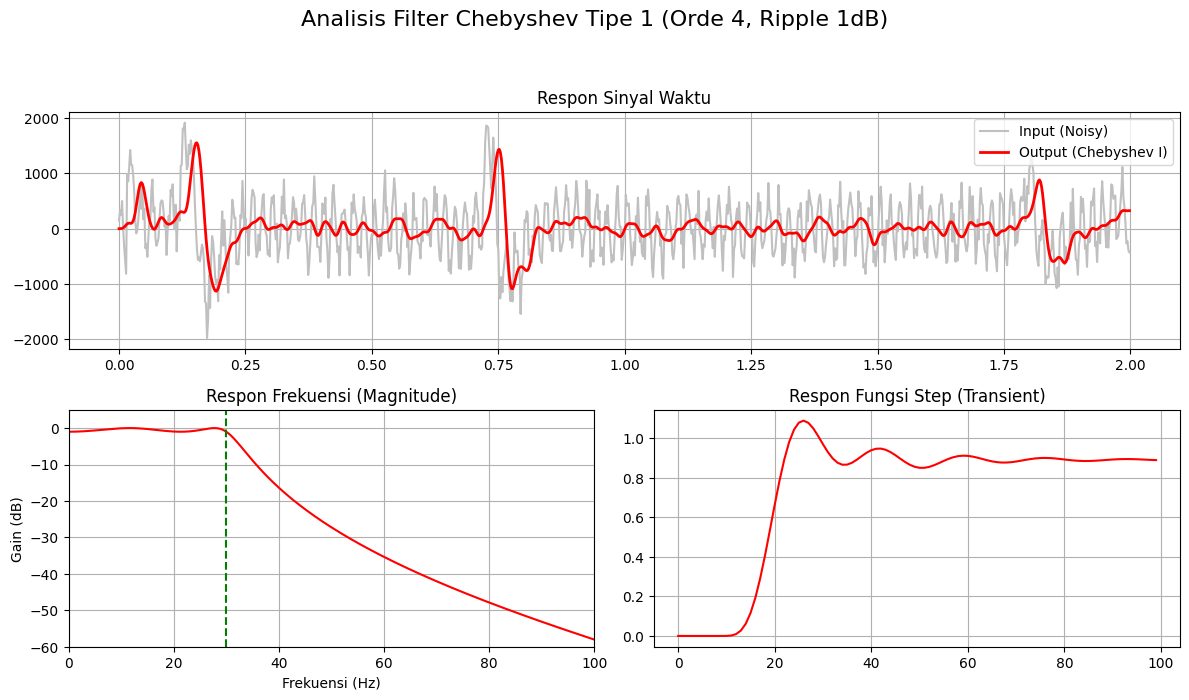

In [ ]:
ripple_db = 1
b_cheb, a_cheb = signal.cheby1(order, ripple_db, normal_cutoff, btype='low', analog=False)
eeg_filtered_cheb = signal.lfilter(b_cheb, a_cheb, eeg_noisy)
plt.figure(figsize=(12, 10))
plt.suptitle(f"Analisis Filter Chebyshev Tipe 1 (Orde {order}, Ripple {ripple_db}dB)", fontsize=16)

plt.subplot(3, 1, 1)
plt.plot(t[:1000], eeg_noisy[:1000], 'silver', label='Input (Noisy)')
plt.plot(t[:1000], eeg_filtered_cheb[:1000], 'r', linewidth=2, label='Output (Chebyshev I)')
plt.title('Respon Sinyal Waktu')
plt.legend(loc='upper right'); plt.grid(True)

w, h = signal.freqz(b_cheb, a_cheb)
plt.subplot(3, 2, 3)
plt.plot(w * fs / (2 * np.pi), 20 * np.log10(abs(h)), 'r')
plt.title('Respon Frekuensi (Magnitude)')
plt.ylabel('Gain (dB)'); plt.xlabel('Frekuensi (Hz)')
plt.axvline(cutoff, color='g', linestyle='--'); plt.ylim(-60, 5); plt.xlim(0, 100); plt.grid(True)

step_in = np.ones(100); step_in[0:10] = 0
step_out = signal.lfilter(b_cheb, a_cheb, step_in)
plt.subplot(3, 2, 4)
plt.plot(step_out, 'r')
plt.title('Respon Fungsi Step (Transient)')
plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Analisis Singkat:pada grafik frekuensi (kiri bawah), garis merah turun lebih tajam/curam daripada Butterworth, tapi ada sedikit gelombang di area 0-30Hz. Pada grafik Step (kanan bawah), garisnya lebih bergetar (ringing).

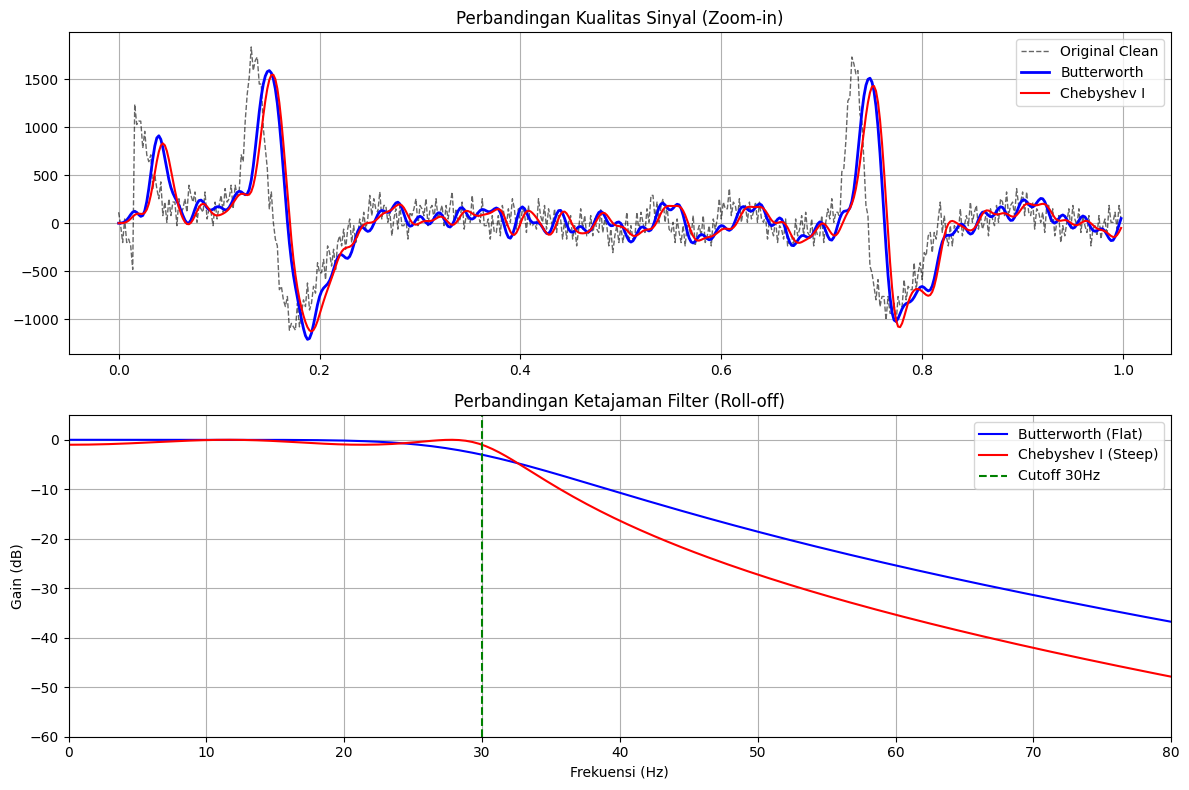

     TABEL EVALUASI PERFORMA (SNR)
SNR Awal (Noisy)   : -1.43 dB
SNR Butterworth    : 0.08 dB
SNR Chebyshev I    : -0.50 dB
----------------------------------------
Kesimpulan: Semakin tinggi nilai dB, sinyal semakin bersih.


In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
zoom = slice(0, 500) # Lihat 1 detik pertama saja
plt.plot(t[zoom], eeg_clean[zoom], 'k--', linewidth=1, alpha=0.6, label='Original Clean')
plt.plot(t[zoom], eeg_filtered_butt[zoom], 'b', linewidth=2, label='Butterworth')
plt.plot(t[zoom], eeg_filtered_cheb[zoom], 'r', linewidth=1.5, label='Chebyshev I')
plt.title('Perbandingan Kualitas Sinyal (Zoom-in)')
plt.legend(); plt.grid(True)

w_b, h_b = signal.freqz(b_butt, a_butt)
w_c, h_c = signal.freqz(b_cheb, a_cheb)

plt.subplot(2, 1, 2)
plt.plot(w_b*fs/(2*np.pi), 20*np.log10(abs(h_b)), 'b', label='Butterworth (Flat)')
plt.plot(w_c*fs/(2*np.pi), 20*np.log10(abs(h_c)), 'r', label='Chebyshev I (Steep)')
plt.axvline(cutoff, color='g', linestyle='--', label='Cutoff 30Hz')
plt.title('Perbandingan Ketajaman Filter (Roll-off)')
plt.xlabel('Frekuensi (Hz)'); plt.ylabel('Gain (dB)')
plt.xlim(0, 80); plt.ylim(-60, 5); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

def calc_snr(signal_vals, noise_vals):
    s = np.mean(signal_vals ** 2)
    n = np.mean(noise_vals ** 2)
    return 10 * np.log10(s / n) if n > 0 else 0

snr_awal = calc_snr(eeg_clean, eeg_noisy - eeg_clean)
snr_butt = calc_snr(eeg_clean, eeg_filtered_butt - eeg_clean)
snr_cheb = calc_snr(eeg_clean, eeg_filtered_cheb - eeg_clean)

print("="*40)
print("     TABEL EVALUASI PERFORMA (SNR)")
print("="*40)
print(f"SNR Awal (Noisy)   : {snr_awal:.2f} dB")
print(f"SNR Butterworth    : {snr_butt:.2f} dB")
print(f"SNR Chebyshev I    : {snr_cheb:.2f} dB")
print("-" * 40)
print("Kesimpulan: Semakin tinggi nilai dB, sinyal semakin bersih.")

=== MENGHUBUNGKAN KE GOOGLE DRIVE ===
Mounted at /content/drive
Membaca file dari: /content/drive/MyDrive/Datasheet EEG.csv
✅ Sukses membaca & membersihkan data!
Sampel valid: 49999
Contoh data awal: [261. 121. -55. 191. -55.]
Mode: Simulasi (Menambahkan Noise Buatan)


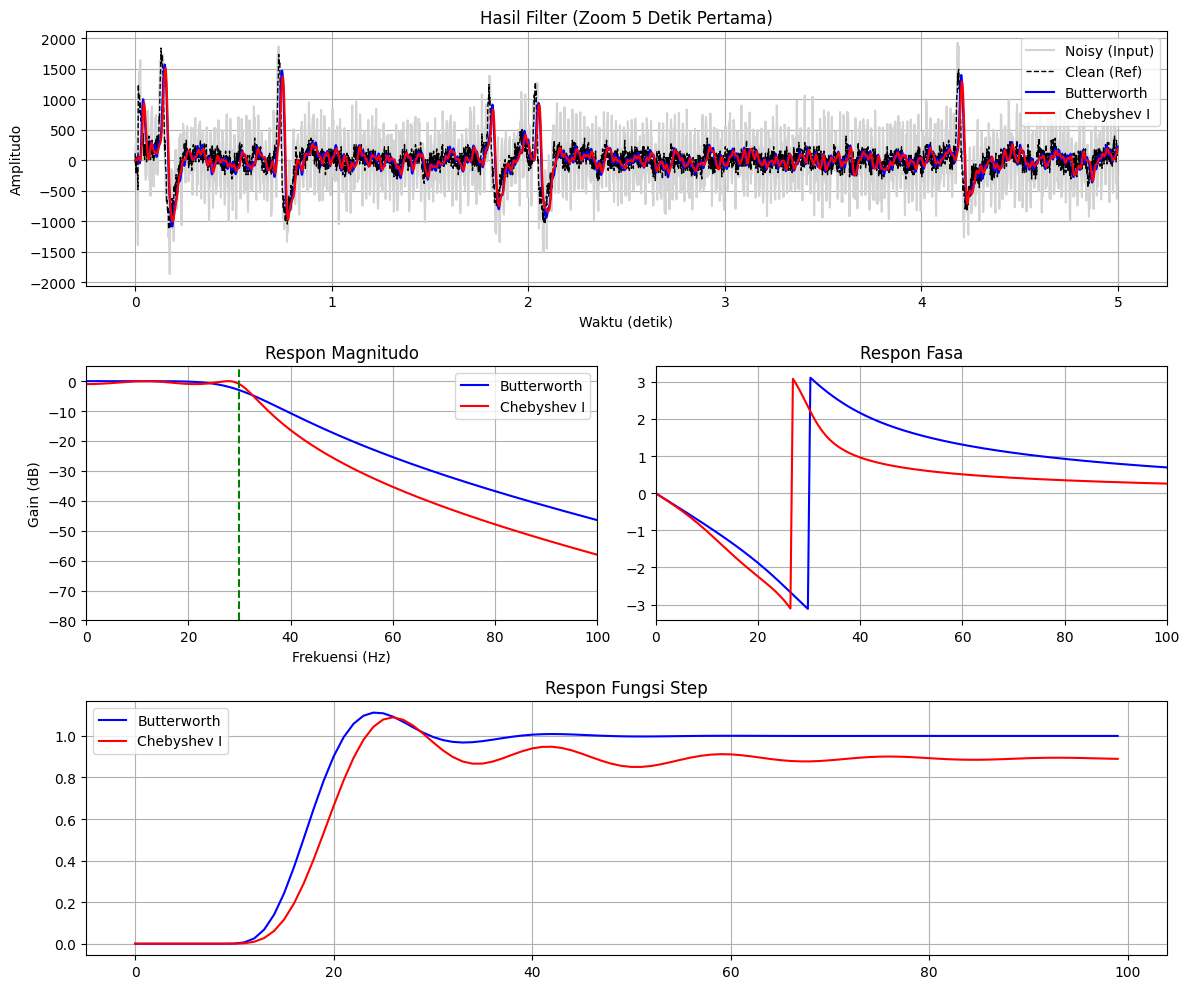

SNR Awal: -1.39 dB
SNR Butterworth: 0.09 dB
SNR Chebyshev: -0.49 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
from google.colab import drive

print("=== MENGHUBUNGKAN KE GOOGLE DRIVE ===")
drive.mount('/content/drive', force_remount=True)

# Lokasi File
path_file = '/content/drive/MyDrive/Datasheet EEG.csv'

print(f"Membaca file dari: {path_file}")
JUMLAH_SAMPEL = 50000

try:
    df = pd.read_csv(path_file, nrows=JUMLAH_SAMPEL, header=None, sep=None, engine='python')
    raw_col = df.iloc[:, 0]
    clean_col = pd.to_numeric(raw_col, errors='coerce')

    clean_col = clean_col.dropna()

    eeg_raw_data = clean_col.values

    if len(eeg_raw_data) == 0:
        raise ValueError("Data kosong setelah pembersihan! Cek isi file CSV.")

    print("✅ Sukses membaca & membersihkan data!")
    print(f"Sampel valid: {len(eeg_raw_data)}")
    print(f"Contoh data awal: {eeg_raw_data[:5]}")

except Exception as e:
    print(f"❌ Terjadi Error: {e}")
    eeg_raw_data = np.sin(2 * np.pi * 10 * np.linspace(0, 2, 1000))

# --- 2. KONFIGURASI PARAMETER ---

fs = 500.0        # Frekuensi sampling (Hz)
n = len(eeg_raw_data)
T = n / fs
t = np.linspace(0, T, n, endpoint=False)

# --- 3. SKENARIO SIMULASI DERAU ---

SIMULASI_TAMBAH_NOISE = True

if SIMULASI_TAMBAH_NOISE:
    eeg_clean = eeg_raw_data
    eeg_clean = eeg_clean - np.mean(eeg_clean)

    noise_random = np.random.normal(0, 0.5 * np.std(eeg_clean), n)
    noise_pln = 1.5 * np.std(eeg_clean) * np.sin(2 * np.pi * 50 * t)
    eeg_noisy = eeg_clean + noise_random + noise_pln
    print("Mode: Simulasi (Menambahkan Noise Buatan)")
else:
    eeg_noisy = eeg_raw_data - np.mean(eeg_raw_data)
    eeg_clean = eeg_noisy
    print("Mode: Real Data")

# --- 4. DESAIN FILTER DIGITAL (IIR) ---

cutoff = 30.0
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
order = 4


b_butt, a_butt = signal.butter(order, normal_cutoff, btype='low', analog=False)
b_cheb, a_cheb = signal.cheby1(order, 1, normal_cutoff, btype='low', analog=False)

eeg_filtered_butt = signal.lfilter(b_butt, a_butt, eeg_noisy)
eeg_filtered_cheb = signal.lfilter(b_cheb, a_cheb, eeg_noisy)

# --- 5. VISUALISASI ---

plt.figure(figsize=(12, 10))
samples_zoom = int(5 * fs)

plt.subplot(3, 1, 1)
plt.plot(t[:samples_zoom], eeg_noisy[:samples_zoom], 'lightgray', label='Noisy (Input)')
if SIMULASI_TAMBAH_NOISE:
    plt.plot(t[:samples_zoom], eeg_clean[:samples_zoom], 'k--', linewidth=1, label='Clean (Ref)')
plt.plot(t[:samples_zoom], eeg_filtered_butt[:samples_zoom], 'b', linewidth=1.5, label='Butterworth')
plt.plot(t[:samples_zoom], eeg_filtered_cheb[:samples_zoom], 'r', linewidth=1.5, label='Chebyshev I')
plt.title('Hasil Filter (Zoom 5 Detik Pertama)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.legend(loc='upper right')
plt.grid(True)

w_butt, h_butt = signal.freqz(b_butt, a_butt)
w_cheb, h_cheb = signal.freqz(b_cheb, a_cheb)
freq_hz_butt = w_butt * fs / (2 * np.pi)
freq_hz_cheb = w_cheb * fs / (2 * np.pi)

plt.subplot(3, 2, 3)
plt.plot(freq_hz_butt, 20 * np.log10(abs(h_butt)), 'b', label='Butterworth')
plt.plot(freq_hz_cheb, 20 * np.log10(abs(h_cheb)), 'r', label='Chebyshev I')
plt.title('Respon Magnitudo')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Gain (dB)')
plt.axvline(cutoff, color='green', linestyle='--')
plt.xlim(0, 100)
plt.ylim(-80, 5)
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq_hz_butt, np.angle(h_butt), 'b')
plt.plot(freq_hz_cheb, np.angle(h_cheb), 'r')
plt.title('Respon Fasa')
plt.xlim(0, 100)
plt.grid(True)

step_input = np.ones(100); step_input[0:10] = 0
r_butt = signal.lfilter(b_butt, a_butt, step_input)
r_cheb = signal.lfilter(b_cheb, a_cheb, step_input)

plt.subplot(3, 1, 3)
plt.plot(r_butt, 'b', label='Butterworth')
plt.plot(r_cheb, 'r', label='Chebyshev I')
plt.title('Respon Fungsi Step')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

def calc_snr(s, n): return 10 * np.log10(np.mean(s**2)/np.mean(n**2))

if SIMULASI_TAMBAH_NOISE:
    print(f"SNR Awal: {calc_snr(eeg_clean, eeg_noisy-eeg_clean):.2f} dB")
    print(f"SNR Butterworth: {calc_snr(eeg_clean, eeg_filtered_butt-eeg_clean):.2f} dB")
    print(f"SNR Chebyshev: {calc_snr(eeg_clean, eeg_filtered_cheb-eeg_clean):.2f} dB")